<a href="https://colab.research.google.com/github/Lekhya-Thota/Lekhya/blob/main/AIML_Module_4_Lab_3_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Prorgam on AIML**
# Module 4: Perceptron and Gradient Descent
## Lab 3: Gradient Descent

Gradient descent is a very important algorithm to understand, as it underpins many of the more advanced algorithms used in Machine Learning and Deep Learning.

A brief overview of the algorithm is


*   start with a random initialization of the solution.
*   incrementally change the solution by moving in the direction of negative gradient of the objective function.
*   repeat the previous step until some convergence criteria is met.

The key equation for change in weight is:
$$w^{k+1} \leftarrow w^k - \eta \Delta J$$

In this lab, we will discuss stochastic gradient descent, mini-batch gradient descent and batch gradient descent.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

# Creating the Data

Let's generate some data with:
\begin{equation} y_0= 4 \end{equation}
\begin{equation} y_1= 3 \end{equation}

and also add some noise to the data.

In [4]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

Let's also plot the data we just created

Text(0, 0.5, 'y')

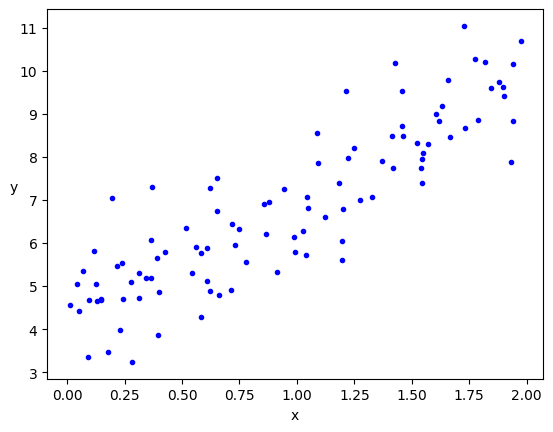

In [5]:
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y', rotation=0)

## Cost Function

The equation for calculating cost function is as shown below. The cost function is only for linear regression. For other algorithms, the cost function will be different and the gradients would have to be derived from the cost functions

\begin{equation}
J(y_{pred}) = \frac{1}{2} m \sum_{i=1}^{m} (h(y_{pred})^{(i)} - y^{(i)})^2
\end{equation}

In [6]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

## Gradients

\begin{equation}
y_{pred_0}: = y_{pred_0} -\alpha . (1/m .\sum_{i=1}^{m}(h(y_{pred}^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}
\begin{equation}
y_{pred_1}: = y_{pred_1} -\alpha . (1/m .\sum_{i=1}^{m}(h(y_{pred}^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}
.

.

.

.

\begin{equation}
y_{pred_j}: = y_{pred_j} -\alpha . (1/m .\sum_{i=1}^{m}(h(y_{pred}^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}

In [7]:
def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    y_pred_history = np.zeros((iterations, 2))

    for it in range(iterations):
        prediction = np.dot(X, y_pred)
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))
        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

Let's do 1000 iterations with a learning rate of 0.01.
We will start with a random prediction.

In [8]:
lr = 0.01
n_iter = 1000

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 3.903
y_pred[1]: 3.046
Final error: 4180.375


Plotting the error vs Number of iterations

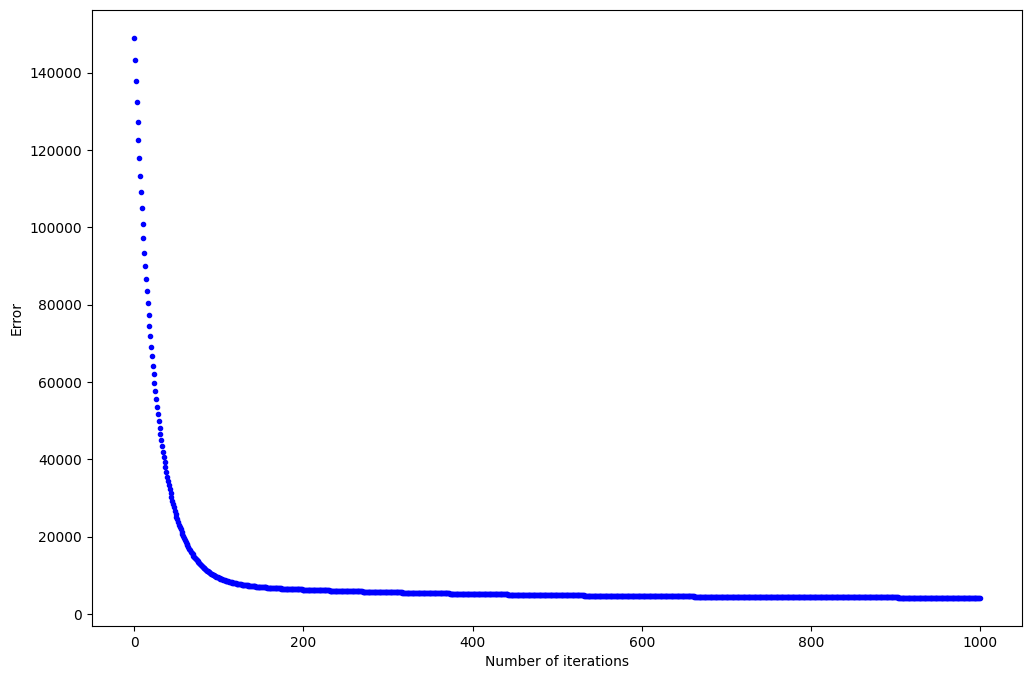

In [9]:
fig, ax = plt.subplots(figsize=(12,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

Zooming in...

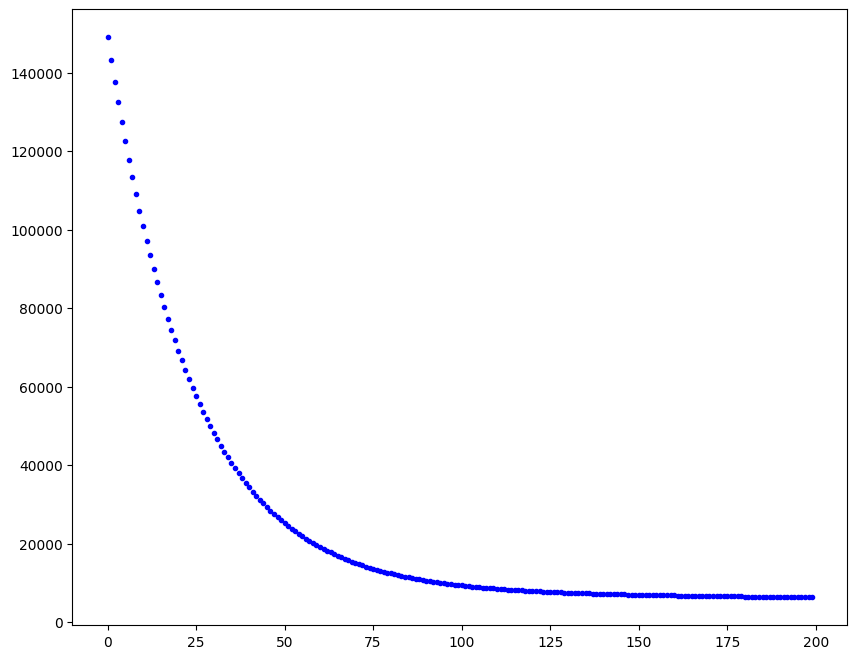

In [10]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(200), cost_history[:200], 'b.')

# Stochastic Gradient Descent

In Batch Gradient Descent we were considering all the examples for every step of Gradient Descent. But what if our dataset is very huge. Deep learning models crave for data. The more the data the more chances of a model to be good. Suppose our dataset has 5 million examples, then just to take one step the model will have to calculate the gradients of all the 5 million examples. This does not seem an efficient way. To tackle this problem we have Stochastic Gradient Descent. In Stochastic Gradient Descent (SGD), we consider just one example at a time to take a single step.

In [11]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [12]:
lr = 0.5
n_iter = 50
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.121
y_pred[1]: 2.755
Final error: 41.313


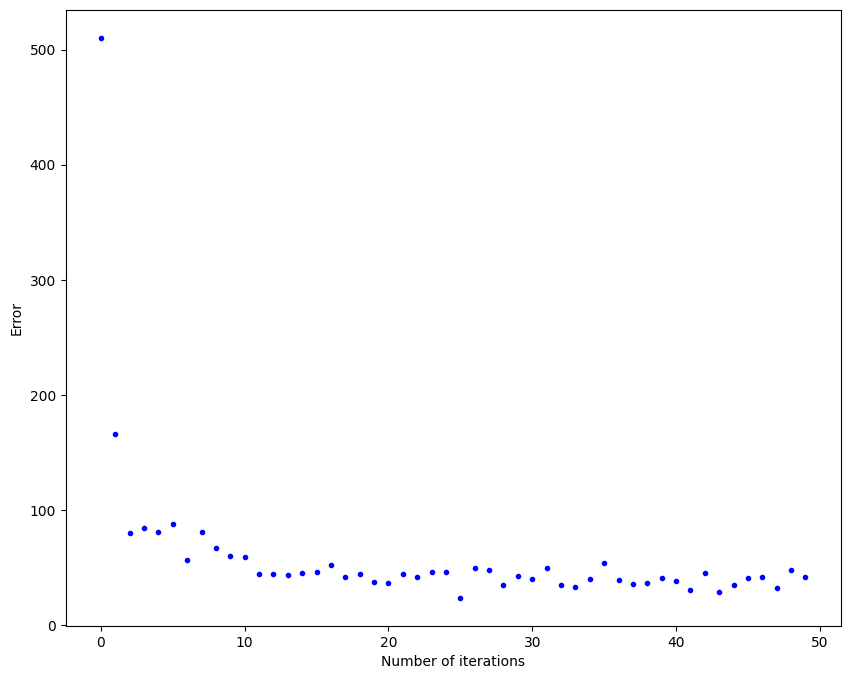

In [13]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

# Mini Batch Gradient Descent

We have seen the Batch Gradient Descent. We have also seen the Stochastic Gradient Descent. Batch Gradient Descent can be used for smoother curves. SGD can be used when the dataset is large. Batch Gradient Descent converges directly to minima. SGD converges faster for larger datasets. But, since in SGD we use only one example at a time, we cannot implement the vectorized implementation on it. This can slow down the computations. To tackle this problem, a mixture of Batch Gradient Descent and SGD is used.
Neither we use all the dataset all at once nor we use the single example at a time. We use a batch of a fixed number of training examples which is less than the actual dataset and call it a mini-batch. Doing this helps us achieve the advantages of both the former variants we saw.

In [14]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [15]:
lr = 0.1
n_iter = 200
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.148
y_pred[1]: 2.827
Final error: 807.488


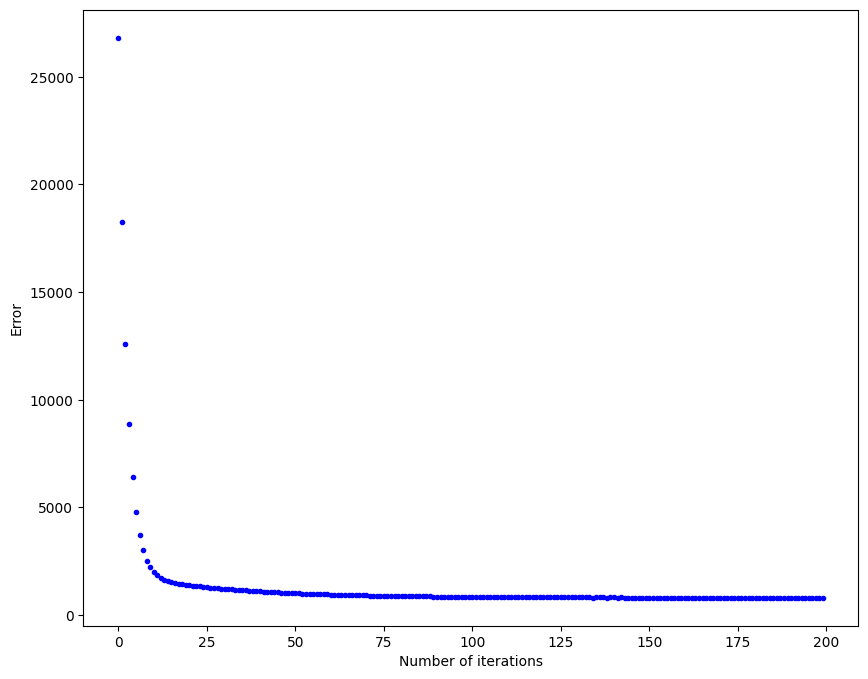

In [16]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

Things to try out:

1. Change batch size in mini-batch gradient descent.
2. Test all the three out on real datasets.
3. Compare the effects of changing learning rate by the same amount in Batch GD, SGD and Mini-batch GD.

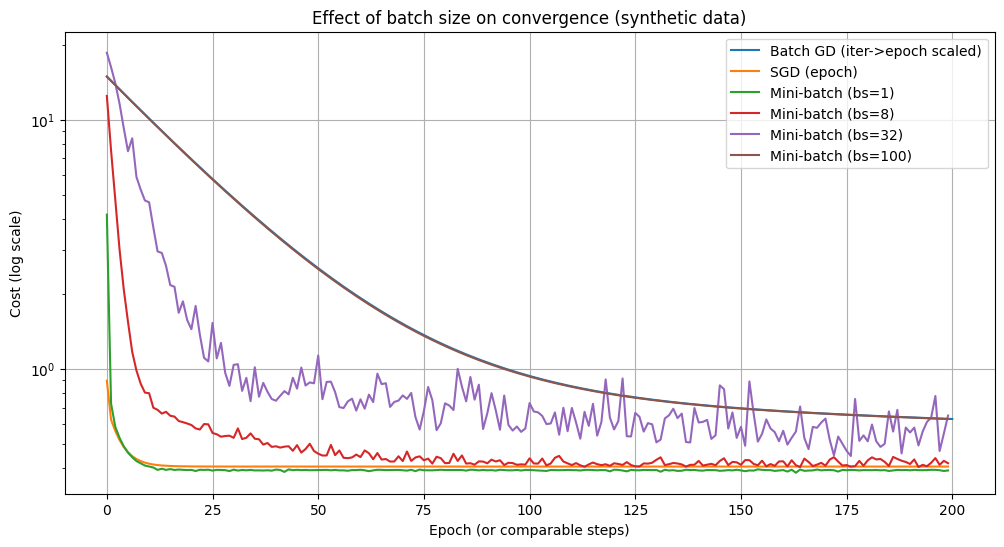

Final costs / times (synthetic):
BatchGD final cost: 0.41803748505887944 time(s): 0.009
SGD final cost: 0.4061087063033931 time(s): 0.067
Mini-batch bs=1: final cost=0.391677, time(s)=0.204
Mini-batch bs=8: final cost=0.418827, time(s)=0.030
Mini-batch bs=32: final cost=0.650650, time(s)=0.010
Mini-batch bs=100: final cost=0.630092, time(s)=0.004

Diabetes dataset example (Batch GD, lr=0.01): Test MSE = 2830.338441938
Diabetes dataset example (Mini-batch GD, lr=0.01, bs=32): Test MSE = 2829.85840246228


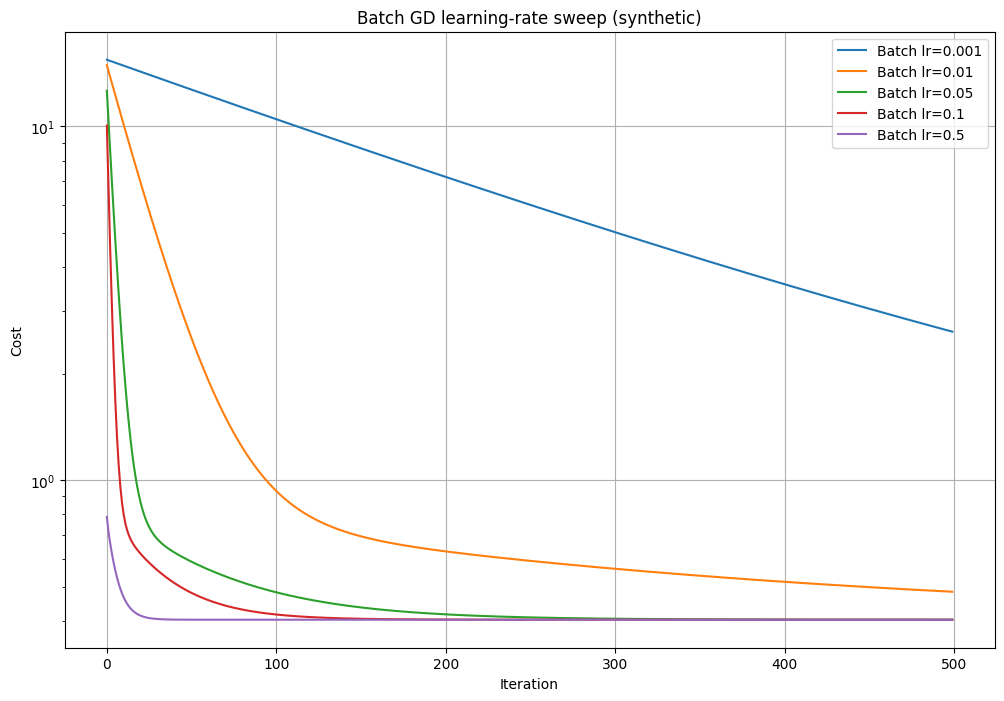

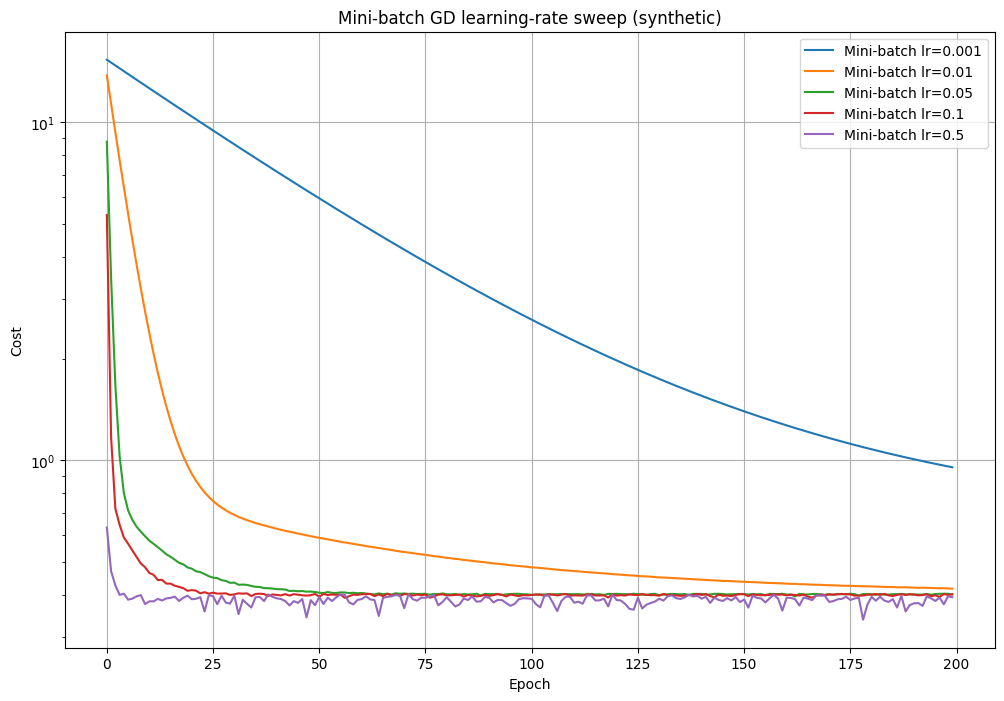

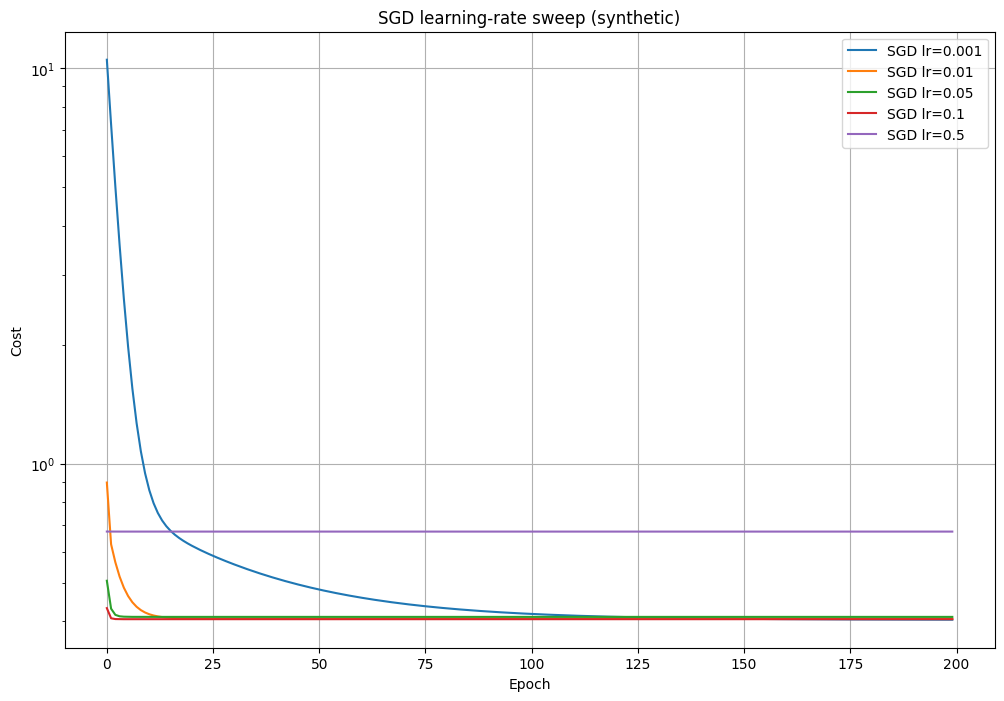


Observations to look for (after you run):
- If lr too large (e.g. 0.5) the curve may diverge/oscillate.
- SGD will be noisy but can make fast early improvements.
- Smaller batch sizes behave like SGD; larger bs approach batch-GD.


In [22]:

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import load_diabetes, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

np.random.seed(42)

def add_bias(X):
    return np.c_[np.ones((X.shape[0],1)), X]

def cost(theta, Xb, y):
    m = len(y)
    preds = Xb.dot(theta)
    return (1/(2*m)) * np.sum((preds - y)**2)

def batch_gd(Xb, y, theta0, lr, n_iters):
    theta = theta0.copy()
    costs, t0 = [], time.time()
    for it in range(n_iters):
        preds = Xb.dot(theta)
        grad = (1/len(y)) * Xb.T.dot(preds - y)
        theta -= lr * grad
        costs.append(cost(theta, Xb, y))
    return theta, costs, time.time()-t0

def sgd(Xb, y, theta0, lr, n_epochs):
    theta = theta0.copy()
    costs, t0 = [], time.time()
    m = len(y)
    for ep in range(n_epochs):
        for i in range(m):
            xi = Xb[i:i+1]
            yi = y[i:i+1]
            pred = xi.dot(theta)
            grad = xi.T.dot(pred - yi)
            theta -= lr * grad  # common variant (no 1/m here)
        costs.append(cost(theta, Xb, y))
    return theta, costs, time.time()-t0

def minibatch_gd(Xb, y, theta0, lr, n_epochs, batch_size): # Modified to accept Xb
    '''
    Xb = Matrix of X with added bias units
    y = Vector of Y
    theta0 = Initial theta vector np.random.randn(j, 1)
    learning_rate
    n_epochs = no of epochs

    Returns the final theta vector and array of cost history over no of epochs
    '''

    theta = theta0.copy()
    costs, t0 = [], time.time()
    m = len(y)
    for ep in range(n_epochs):
        cost_epoch = 0.0 # Initialize cost for each epoch
        indices = np.random.permutation(m)
        Xbs = Xb[indices] # Use Xb here
        ys = y[indices]

        for start in range(0, m, batch_size):
            xb = Xbs[start:start+batch_size]
            yb = ys[start:start+batch_size]

            prediction = np.dot(xb, theta) # Use theta here
            grad = (1/len(yb))* xb.T.dot((prediction - yb)) # Use theta here
            theta -= lr * grad
            cost_epoch += cost(theta, xb, yb) # Calculate cost for the mini-batch

        costs.append(cost_epoch / (m/batch_size)) # Append average cost per epoch

    return theta, costs, time.time()-t0


X = 2 * np.random.rand(100,1)
y = 4 + 3*X + np.random.randn(100,1)
Xb = add_bias(X)
theta0 = np.random.randn(2,1)


batch_sizes = [1, 8, 32, 100]  # 100 ~ full batch
lr = 0.01
n_epochs = 200   # epochs for sgd/minibatch
n_iters_batch = 1000  # iterations for batch (comparable)
results_bs = {}

for bs in batch_sizes:
    # mini-batch
    theta_m, costs_m, t_m = minibatch_gd(Xb, y, theta0.copy(), lr, n_epochs, batch_size=bs) # Pass Xb
    results_bs[bs] = {'theta': theta_m, 'costs': costs_m, 'time': t_m}


theta_b, costs_b, t_b = batch_gd(Xb, y, theta0.copy(), lr, n_iters_batch)
theta_s, costs_s, t_s = sgd(Xb, y, theta0.copy(), lr, n_epochs)

# Plot results: align x-axis = epochs (for comparability)
plt.figure(figsize=(12,6))
# batch (we'll plot its first n_epochs points for comparison)
plt.plot(np.linspace(0,n_epochs,len(costs_b[:n_epochs])), costs_b[:n_epochs], label='Batch GD (iter->epoch scaled)')
plt.plot(range(len(costs_s)), costs_s, label='SGD (epoch)')
for bs in batch_sizes:
    plt.plot(range(len(results_bs[bs]['costs'])), results_bs[bs]['costs'], label=f'Mini-batch (bs={bs})')
plt.yscale('log')
plt.xlabel('Epoch (or comparable steps)')
plt.ylabel('Cost (log scale)')
plt.title('Effect of batch size on convergence (synthetic data)')
plt.legend()
plt.grid(True)
plt.show()

print("Final costs / times (synthetic):")
print("BatchGD final cost:", costs_b[-1], "time(s):", round(t_b,3))
print("SGD final cost:", costs_s[-1], "time(s):", round(t_s,3))
for bs in batch_sizes:
    print(f"Mini-batch bs={bs}: final cost={results_bs[bs]['costs'][-1]:.6f}, time(s)={results_bs[bs]['time']:.3f}")


data = load_diabetes()
Xd = data.data
yd = data.target.reshape(-1,1)
# Standardize features and response (helps optimization)
scalerX = StandardScaler().fit(Xd)
Xds = scalerX.transform(Xd)
# Bias term
Xb_d = add_bias(Xds)
# train-test split
Xtr, Xte, ytr, yte = train_test_split(Xb_d, yd, test_size=0.3, random_state=42)

theta0_d = np.random.randn(Xtr.shape[1],1)

# Run mini-batch and batch with a couple of lr values
lr_list = [0.001, 0.01, 0.1]
n_epochs = 100
batch_size = 32

results_real = {}
for lr in lr_list:
    # Run batch_gd on Xtr (with bias)
    th_b, costs_b_real, t_b_real = batch_gd(Xtr, ytr, theta0_d.copy(), lr, n_iters=500)
    # Run minibatch_gd on Xtr (with bias)
    th_m, costs_m_real, t_m_real = minibatch_gd(Xtr, ytr, theta0_d.copy(), lr, n_epochs, batch_size) # Pass Xtr
    results_real[lr] = {'batch_theta': th_b, 'batch_costs': costs_b_real, 'batch_time': t_b_real,
                        'mini_theta': th_m, 'mini_costs': costs_m_real, 'mini_time': t_m_real}


# Evaluate final batch model for lr=0.01 as example
th_b_example = results_real[0.01]['batch_theta']
y_pred_te_b = Xte.dot(th_b_example)
mse_test_b = mean_squared_error(yte, y_pred_te_b)
print("\nDiabetes dataset example (Batch GD, lr=0.01): Test MSE =", mse_test_b)

# Evaluate final minibatch model for lr=0.01 as example
th_m_example = results_real[0.01]['mini_theta']
y_pred_te_m = Xte.dot(th_m_example)
mse_test_m = mean_squared_error(yte, y_pred_te_m)
print("Diabetes dataset example (Mini-batch GD, lr=0.01, bs=32): Test MSE =", mse_test_m)


lr_values = [0.001, 0.01, 0.05, 0.1, 0.5]
trace = {}
for lr in lr_values:
    th_b, costs_b, t_b = batch_gd(Xb, y, theta0.copy(), lr, n_iters=500)
    th_s, costs_s, t_s = sgd(Xb, y, theta0.copy(), lr, n_epochs=200)
    th_m, costs_m, t_m = minibatch_gd(Xb, y, theta0.copy(), lr, n_epochs=200, batch_size=20) # Pass Xb
    trace[lr] = {'batch': (th_b, costs_b), 'sgd': (th_s, costs_s), 'mini': (th_m, costs_m)}

plt.figure(figsize=(12,8))
for lr in lr_values:
    plt.plot(trace[lr]['batch'][1], label=f'Batch lr={lr}')
plt.yscale('log')
plt.title('Batch GD learning-rate sweep (synthetic)')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

# Plot mini-batch learning rate sweep
plt.figure(figsize=(12,8))
for lr in lr_values:
    plt.plot(trace[lr]['mini'][1], label=f'Mini-batch lr={lr}')
plt.yscale('log')
plt.title('Mini-batch GD learning-rate sweep (synthetic)')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

# Plot SGD learning rate sweep
plt.figure(figsize=(12,8))
for lr in lr_values:
    plt.plot(trace[lr]['sgd'][1], label=f'SGD lr={lr}')
plt.yscale('log')
plt.title('SGD learning-rate sweep (synthetic)')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

print("\nObservations to look for (after you run):")
print("- If lr too large (e.g. 0.5) the curve may diverge/oscillate.")
print("- SGD will be noisy but can make fast early improvements.")
print("- Smaller batch sizes behave like SGD; larger bs approach batch-GD.")

## **Additional Critical Thinking Question**



**Which of the following is TRUE, given the optimal learning rate?**

 (i) Batch gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (ii) Stochastic gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (iii) For convex loss functions (i.e. with a bowl shape), batch gradient descent is guaranteed to eventually converge to the global optimum while stochastic gradient descent is not.

 (iv) For convex loss functions (i.e. with a bowl shape), stochastic gradient descent is guaranteed to eventually converge to the global optimum while batch gradient descent is not.

 (v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

 (vi) For convex loss functions (i.e. with a bowl shape), neither stochastic gradient descent nor batch gradient descent are guaranteed to converge to the global optimum.

 (V)